In [1]:
import torch
from IPython import display
from d2l import torch as d2l


batch_size = 256
train_iter,test_iter = d2l.load_data_fashion_mnist(batch_size)

In [2]:
#初始化模型参数
num_inputs = 784
num_outputs = 10

W = torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b = torch.zeros(num_outputs,requires_grad=True)

In [3]:
#定义softmax操作
X  = torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
X.sum(0,keepdim=True),X.sum(1,keepdim=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

对每个项求幂（使用exp）；

对每一行求和（小批量中每个样本是一行），得到每个样本的规范化常数；

将每一行除以其规范化常数，确保结果的和为1。

In [4]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1,keepdim=True)
    return X_exp/partition

In [5]:
X=torch.normal(0,1,(2,5))
X_porb = softmax(X)
X_porb,X_porb.sum(1)

(tensor([[0.0204, 0.1753, 0.4679, 0.2302, 0.1063],
         [0.4073, 0.2218, 0.2271, 0.0271, 0.1167]]),
 tensor([1.0000, 1.0000]))

In [6]:
#定义模型
def net(X):
    return softmax(torch.matmul(X.reshape((-1,W.shape[0])),W) + b)
# y_hat=softmax(XW+b)

In [7]:
#定义损失函数
y = torch.tensor([0,2])
y_hat = torch.tensor([[0.1,0.3,0.6],[0.3,0.2,0.5]])
y_hat[[0,1],y]

tensor([0.1000, 0.5000])

In [8]:
def cross_entropy(y_hat,y):#交叉熵损失
    return -torch.log(y_hat[range(len(y_hat)),y])#->log(1)=0,loss->0,返值越小，准确率越高
cross_entropy(y_hat,y)

tensor([2.3026, 0.6931])

In [9]:
#分类精度
def accuracy(y_hat,y):
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat = y_hat.argmax(axis=1)#寻找最大值的索引
    cmp=y_hat.type(y.dtype)==y
    return float(cmp.type(y.dtype).sum())#预测正确的样本个数

In [10]:
accuracy(y_hat, y) / len(y)

0.5

In [11]:
#定义评估函数
def evaluate_accuracy(net,data_iter):
    if isinstance(net,torch.nn.Module):
        net.eval()
    metric = Accumulator(2)
    with torch.no_grad():
        for X,y in data_iter:
            metric.add(accuracy(net(X),y),y.numel())
    return metric[0]/metric[1]

In [12]:
class Accumulator:
    def __init__(self,n):
        self.data=[0.0]*n
    def add(self,*args):
        self.data=[a+float(b) for a,b in zip(self.data,args)]
    def reset(self):
        self.data=[0.0]*len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [13]:
evaluate_accuracy(net, test_iter)

0.1384

In [14]:
#训练
def train_epoch_ch3(net,train_iter,loss,updater):
    if isinstance(net,torch.nn.Module):
        net.train()
    metric = Accumulator(3)
    for X,y in train_iter:
        y_hat = net(X)#预测
        l = loss(y_hat,y)#损失
        if isinstance(updater,torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()#梯度
            updater.step()#更新参数
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()),accuracy(y_hat,y),y.numel())#记录
    return  metric[0]/metric[2],metric[1]/metric[2]#平均损失, 训练准确率

In [15]:
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

In [16]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3,0.9],legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)#训练
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <= 1 and test_acc > 0.7, test_acc

In [17]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

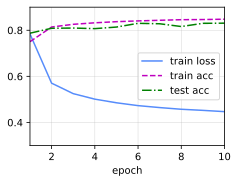

In [18]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

softmax的简洁实现

In [19]:
import torch
from torch import nn
from d2l import torch as d2l
batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)


In [20]:
#初始化模型参数
net = nn.Sequential(nn.Flatten(),nn.Linear(784,10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,std=0.01)
net.apply(init_weights);

In [21]:
loss = nn.CrossEntropyLoss(reduction='none')

In [22]:
#优化算法
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

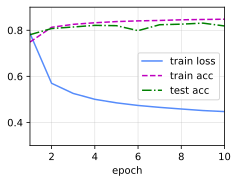

In [23]:
#训练
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)